# UNEMPLOYMENT RATE DATASET ANALYSIS

### OVERVIEW
The dataset comprises of 500 records across 7 attributes focuses to protrait the unemployment rate in India during the period of 2018-2024 across various dimensions such as time, geography, age and gender. By showcasing regional disparities and demographic inbalance the analysis aims to provide relevant insights that can inform evidence-based governance and targeted employment interventions.

### Important Questions to be Uncover:
- Which states have the highest and lowest unemployment rate?
- Show the unemployment trend in India  during the period 2018-2024.
- Which quarter (Q1–Q4) consistently shows the highest or lowest average unemployment rate across 2018–2024?
- Which gender face the unemployment burden the most?
- Is youth unemployment (15-29 years) significantly higher than other age groups? 
- In the state with the highest unemployment rate, which gender and age group face the greatest unemployment burden?
- How did quarterly unemployment rates evolve between 2018 and 2024, particularly in response to the pandemic spike of 2019–2021, and what observable signs of recovery can be noted in the subsequent years?
- Which states consistently show unemployment rates above or below the national average?

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\DHANYA\Downloads\Unemployment Rate (UR)_Sample_Data.csv")
print("Dataset is loaded successfully!")

Dataset is loaded successfully!


In [3]:
df

,Year (year),Report Period (quarter),State Name (state_name),Age Group (age_group),Gender (gender),Unemployment Rate (value),State Code (state_code)
0,2021,January-March,Gujarat,15-29 Years,Female,10.4,24
1,2020,July-September,West Bengal,All,Person,10.7,19
2,2023,January-March,Uttarakhand,15 Years And Above,Female,8.6,5
3,2024,January-March,Jammu And Kashmir,15 Years And Above,Person,11.0,1
4,2023,April-June,Madhya Pradesh,All,Person,7.7,23
...,...,...,...,...,...,...,...
495,2023,July-September,Karnataka,15 Years And Above,Male,4.2,29
496,2020,April-June,Chhattisgarh,15 Years And Above,Male,16.1,22
497,2019,April-June,Uttarakhand,15-29 Years,Male,19.7,5
498,2021,April-June,Kerala,15 Years And Above,Female,28.4,32


### Data Cleaning

In [4]:
# Check data types
df.dtypes

Year (year)                    int64
Report Period (quarter)       object
State Name (state_name)       object
Age Group (age_group)         object
Gender (gender)               object
Unemployment Rate (value)    float64
State Code (state_code)        int64
dtype: object

In [5]:
# Checking Missing Values
df.isnull().sum()

Year (year)                  0
Report Period (quarter)      0
State Name (state_name)      0
Age Group (age_group)        0
Gender (gender)              0
Unemployment Rate (value)    0
State Code (state_code)      0
dtype: int64

In [6]:
# Checking Duplicate Values
df.duplicated().sum()

np.int64(0)

### Statistical Summary of Numerical Columns

In [10]:
df.describe()

,Year (year),Unemployment Rate (value),State Code (state_code)
count,500.000000,500.000000,500.000000
mean,2020.846000,15.448600,19.272000
std,1.661266,10.397794,17.942181
min,2018.000000,1.700000,1.000000
25%,2019.000000,8.100000,6.750000
50%,2021.000000,11.900000,19.500000
75%,2022.000000,20.725000,27.000000
max,2024.000000,60.800000,99.000000


### Statistical Summary of Categorical Columns

In [12]:
df.describe(include=object)

,Report Period (quarter),State Name (state_name),Age Group (age_group),Gender (gender)
count,500,500,500,500
unique,4,23,3,3
top,October-December,Punjab,15 Years And Above,Female
freq,143,35,174,173


## Exploratory Data Analysis (EDA)

### 1. Unemployment Rates by State

In [15]:
state_uemp = df.groupby('State Name (state_name)')['Unemployment Rate (value)'].mean().reset_index()

In [16]:
state_unemp_sort = state_uemp.sort_values(by='Unemployment Rate (value)' , ascending = False)

In [20]:
# Display the states with highest Unemployment Rate
print("Top 5 highest Unemployment Rate States:")
print(state_unemp_sort.head(5))

Top 5 highest Unemployment Rate States:
   State Name (state_name)  Unemployment Rate (value)
12                  Kerala                  26.366667
17               Rajasthan                  23.371429
9        Jammu And Kashmir                  22.985185
19               Telangana                  20.123529
21             Uttarakhand                  19.172727


In [32]:
# Display the States with lowest Unemployment rate 
print("Least 5 Unemployment Rate States:")
print(state_unemp_sort.tail())

Least 5 Unemployment Rate States:
   State Name (state_name)  Unemployment Rate (value)
3                    Bihar                  12.560000
5                    Delhi                   9.315000
11               Karnataka                   9.270000
22             West Bengal                   8.608333
6                  Gujarat                   6.300000


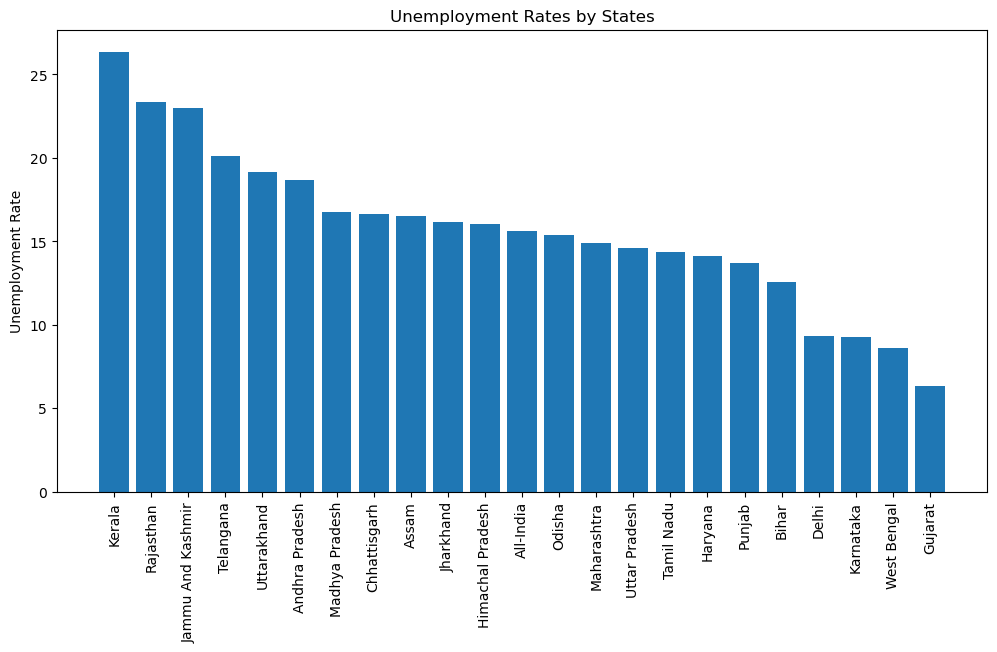

In [31]:
#Visualization of Unemployment rate with States
plt.figure(figsize=(12,6))
plt.bar(state_unemp_sort['State Name (state_name)'], state_unemp_sort['Unemployment Rate (value)'])
plt.title('Unemployment Rates by States')
plt.xticks(rotation=90)
plt.ylabel('Unemployment Rate')
plt.show()         

##### Findings:
- Kerala has the highest unemployment rate among all states, follows by Rajasthan, Jammu and Kashmir.
- Gujarat has the least unemployment rate, followed by West Bengal, Karnataka.

### 2. Unemployment Trend in India (2018-2024)

In [41]:
year_unemp = df.groupby('Year (year)')['Unemployment Rate (value)'].mean().reset_index()

In [42]:
year_unemp

,Year (year),Unemployment Rate (value)
0,2018,14.851282
1,2019,15.979121
2,2020,19.423864
3,2021,15.477174
4,2022,14.886364
5,2023,13.101190
6,2024,8.183333


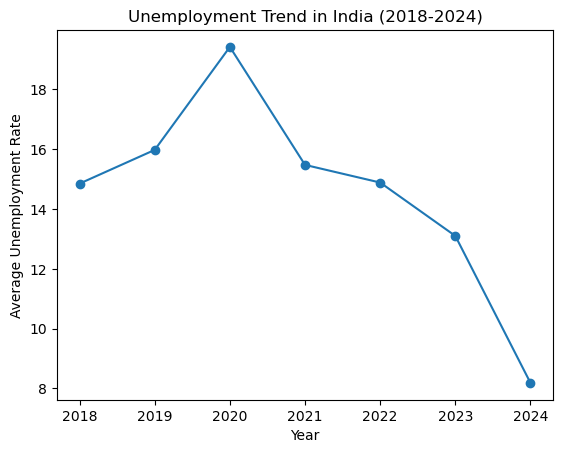

In [43]:
# Visualization of India's unemployment trend using line chart
plt.plot(year_unemp['Year (year)'],year_unemp['Unemployment Rate (value)'],marker='o')
plt.title("Unemployment Trend in India (2018-2024)")
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate')
plt.show()

##### Findings:
- From the chart it cleared that the country experience peak unemployment from 2019 to 2021. Especially during 2020. This might happened because of the Covid outbreak during those years.
- However, in the year 2024 the unemployment rate declined below 10%.

### 3. Seasonal Unemployment Trend

In [55]:
seasonal_unemp = df.groupby('Report Period (quarter)')['Unemployment Rate (value)'].mean().reset_index()

In [80]:
seasonal_unemp 

,Report Period (quarter),Unemployment Rate (value)
0,April-June,19.410000
1,January-March,13.844604
2,July-September,14.965254
3,October-December,14.636364


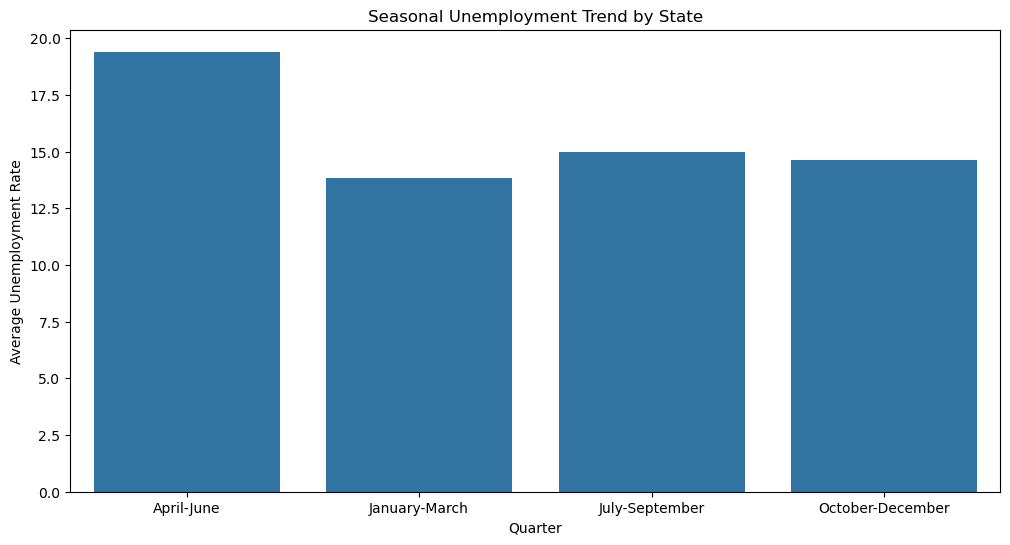

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(data=seasonal_unemp, x= 'Report Period (quarter)', y='Unemployment Rate (value)')
plt.title('Seasonal Unemployment Trend by State')
plt.xlabel('Quarter')
plt.ylabel('Average Unemployment Rate')
plt.show()

##### Findings:
- The highest unemployment presist in the April-June (19.41%) quarter. This might happen due to fiscal transistion or agircultural cycle(post_harvest lull).
- Others including July-September (14.96%) and October–December (14.63%) shows a moderate unemployment range, showing relatively stable unemployment compared to the extremes.
- January–March (13.84%) shows the lowest average unemployment. This might be due to active agricultural work or stable economic activity.

### 4. Gender Employment Disparity

In [62]:
gender_unemp = df.groupby('Gender (gender)')['Unemployment Rate (value)'].mean().reset_index()

In [67]:
gender_unemp

,Gender (gender),Unemployment Rate (value)
0,Female,18.468786
1,Male,12.283750
2,Person,15.352096


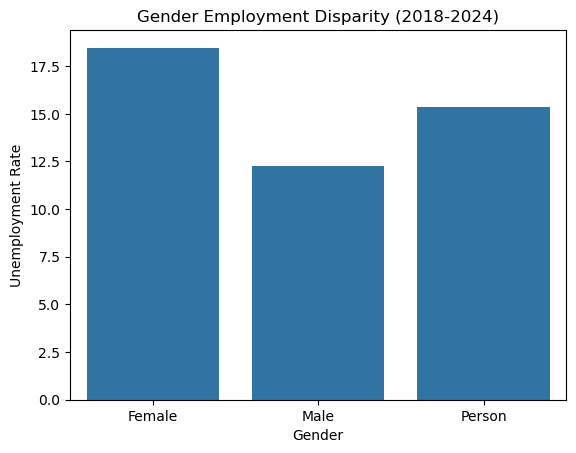

In [65]:
sns.barplot(data=gender_unemp,x='Gender (gender)',y='Unemployment Rate (value)')
plt.title('Gender Employment Disparity (2018-2024)')
plt.xlabel('Gender')
plt.ylabel('Unemployment Rate')
plt.show()

##### Findings:
- The female group has the highest average unemployment rate at 18.47%, which is significantly higher than both males and the overall population.
- The male group shows a lower average unemployment rate of 12.28%, indicating relatively better employment outcomes compared to females.
- The overall population (Person) has an average unemployment rate of 15.35%, which lies between the male and female averages.

### 5. Unemployment Rate by Age Group

In [69]:
age_unemp = df.groupby('Age Group (age_group)')['Unemployment Rate (value)'].mean().reset_index()

In [70]:
age_unemp

,Age Group (age_group),Unemployment Rate (value)
0,15 Years And Above,10.806897
1,15-29 Years,25.150588
2,All,10.053205


##### Findings:
- The age group 15-29 years has the highest unemployment rate of 25.15%.
- The overall population's (All) average unemployment rate is 10% which indicates that the youth unemployment significantly higher than other age groups. 

### 6. Kerala Unemployment Pattern: Gender and Age Group Disparities

In [28]:
Kerala_unemp = df[df['State Name (state_name)'] == 'Kerala']

In [30]:
gender_Kerala_unemp = Kerala_unemp.groupby('Gender (gender)')['Unemployment Rate (value)'].mean().reset_index()
print(gender_Kerala_unemp)

  Gender (gender)  Unemployment Rate (value)
0          Female                  31.383333
1            Male                  13.150000
2          Person                  25.450000


In [35]:
age_Kerala_unemp = Kerala_unemp.groupby('Age Group (age_group)')['Unemployment Rate (value)'].mean().reset_index()
print(age_Kerala_unemp)                                     

  Age Group (age_group)  Unemployment Rate (value)
0    15 Years And Above                  19.366667
1           15-29 Years                  42.225000
2                   All                  17.880000


##### Findings:
- In Kerala the highest unemployment issue faced by youth female (15-29 Years).

### 7. Combined Year–Quarter Unemployment Trend Analysis (2018–2024)

In [24]:
trend_unemp = df.groupby(['Year (year)','Report Period (quarter)'])['Unemployment Rate (value)'].mean().reset_index()
trend_unemp

,Year (year),Report Period (quarter),Unemployment Rate (value)
0,2018,July-September,14.487500
1,2018,October-December,15.104348
2,2019,April-June,18.504167
3,2019,January-March,17.877778
4,2019,July-September,12.382353
5,2019,October-December,13.773913
6,2020,April-June,24.519048
7,2020,January-March,14.722727
8,2020,July-September,20.678947
9,2020,October-December,18.369231


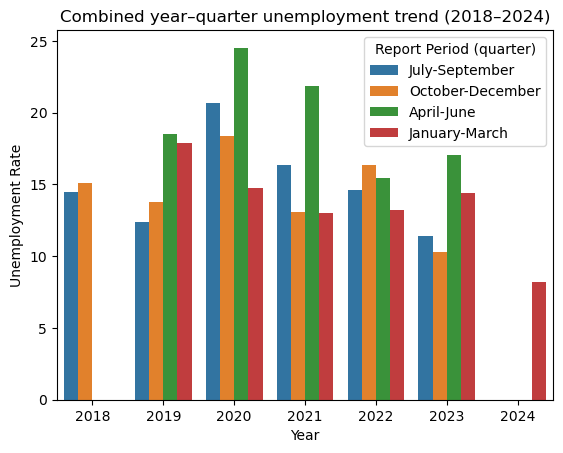

In [26]:
sns.barplot( data=trend_unemp,x= 'Year (year)',y='Unemployment Rate (value)',hue= 'Report Period (quarter)' )
plt.title('Combined year–quarter unemployment trend (2018–2024)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate')
plt.show()

##### Findings:
- The unemployment spike up in the year 2019-2021, peaking in April-June 2020(24.5%) That reflecting the pandemic's impact.
- However,  the year after 2020 can be recorded as recovery phase where unemployment gradually declines, with notable improvement by 2024 (Jan–Mar: 8.18%), the lowest in the dataset.

### 8. State consistency vs national average

In [10]:
national_avg = df.groupby('Year (year)')['Unemployment Rate (value)'].mean()

In [11]:
national_avg

Year (year)
2018    14.851282
2019    15.979121
2020    19.423864
2021    15.477174
2022    14.886364
2023    13.101190
2024     8.183333
Name: Unemployment Rate (value), dtype: float64

In [17]:
state_avg=df.groupby(['State Name (state_name)','Year (year)'])['Unemployment Rate (value)'].mean().reset_index()

In [18]:
state_avg

,State Name (state_name),Year (year),Unemployment Rate (value)
0,All-India,2019,9.800000
1,All-India,2020,29.933333
2,All-India,2021,15.660000
3,All-India,2022,9.480000
4,All-India,2024,15.100000
...,...,...,...
141,West Bengal,2020,11.860000
142,West Bengal,2021,7.975000
143,West Bengal,2022,6.837500
144,West Bengal,2023,7.020000


In [20]:
state_consistency = state_avg.groupby('State Name (state_name)')['Unemployment Rate (value)'].mean()-national_avg.mean()

In [22]:
print(state_consistency.sort_values())

State Name (state_name)
Gujarat              -8.152714
Karnataka            -5.544210
West Bengal          -4.675392
Delhi                -4.373428
Haryana              -2.602714
Punjab               -2.286047
Bihar                -1.946761
Himachal Pradesh     -0.508666
Uttar Pradesh        -0.209420
Maharashtra          -0.063666
Jharkhand             0.009866
Madhya Pradesh        0.309191
Odisha                0.533858
All-India             1.437191
Tamil Nadu            1.737525
Assam                 1.916136
Chhattisgarh          2.048080
Andhra Pradesh        4.241096
Uttarakhand           4.903919
Jammu And Kashmir     6.676334
Rajasthan             7.528358
Telangana             7.995525
Kerala               15.159191
Name: Unemployment Rate (value), dtype: float64


##### Findings:
- States with consistently lower unemployment than the national average (negative values):
Gujarat, Karnataka, West Bengal, Delhi, Haryana, Punjab, and Bihar stand out as structurally stronger performers. These states may have stronger labor markets, diversified economies, or better employment opportunities.
- States hovering around the national average:
Jharkhand, Madhya Pradesh, Odisha, Maharashtra, and Uttar Pradesh show unemployment rates close to the national mean. These states reflect the typical Indian unemployment pattern, neither persistently high nor low.
- States with persistently higher unemployment (positive values):
Kerala, Telangana, Rajasthan, Jammu & Kashmir, Uttarakhand, and Andhra Pradesh. These states face chronic unemployment challenges including mismatches between education and jobs, rapid population growth, and slow industrial expansion.  